# SIS421 - Inteligencia Artificial II
## Pipeline Multimodal de Alta Precisión para la Detección de Trampas
Este cuadernillo gestiona la descarga, el entrenamiento con RetinaNet (Torchvision), la ingeniería de datos y el entrenamiento robusto de un clasificador denso incorporando Early Stopping, Learning Rate Schedulers y Checkpoints.

In [5]:
import torch
import os
import sys
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

print(f'Entorno Python: {sys.executable}')
print(f'Versión de PyTorch: {torch.__version__}')
cuda_status = torch.cuda.is_available()
print(f'CUDA (GPU) disponible: {"Sí" if cuda_status else "No"}')
if cuda_status:
    print(f'Tarjeta gráfica activa: {torch.cuda.get_device_name(0)}')

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

Entorno Python: d:\quinto_semestre\anaconda\envs\env_sis421\python.exe
Versión de PyTorch: 2.5.1
CUDA (GPU) disponible: Sí
Tarjeta gráfica activa: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key='apikey.txt')
project = rf.workspace('savitris-workspace').project('cheating-detection-37r8t')
dataset = project.version(3).download('yolov8')

if os.path.exists(dataset.location) and not os.path.exists('data/roboflow_data'):
    os.rename(dataset.location, 'data/roboflow_data')
    print('Dataset descargado y ubicado en data/roboflow_data.')

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import cv2
import glob
import yaml
import torchvision
from PIL import Image

with open('data/roboflow_data/data.yaml', 'r') as f:
    config_dataset = yaml.safe_load(f)

clases = config_dataset['names']
phone_id, paper_id = -1, -1
for idx, name in enumerate(clases):
    n_lower = name.lower()
    if 'phone' in n_lower or 'celular' in n_lower: phone_id = idx
    if 'paper' in n_lower or 'book' in n_lower or 'cheating' in n_lower or 'papel' in n_lower: paper_id = idx

print(f'Mapeo de clases: ID Celular: {phone_id} | ID Papel/Libro: {paper_id}')

class RetinaDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.image_paths = glob.glob(f"{root_dir}/images/*.jpg")

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

        boxes = []
        labels = []
        img_w, img_h = img.size
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    c = int(float(parts[0]))
                    
                    if len(parts) == 5:
                        x, y, w, h = map(float, parts[1:])
                        xmin = (x - w/2) * img_w
                        ymin = (y - h/2) * img_h
                        xmax = (x + w/2) * img_w
                        ymax = (y + h/2) * img_h
                    else:
                        coords = list(map(float, parts[1:]))
                        xs = coords[0::2]
                        ys = coords[1::2]
                        xmin = min(xs) * img_w
                        ymin = min(ys) * img_h
                        xmax = max(xs) * img_w
                        ymax = max(ys) * img_h
                    
                    xmin, ymin = max(0, xmin), max(0, ymin)
                    xmax, ymax = min(img_w, xmax), min(img_h, ymax)
                    
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(c + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        if len(boxes) == 0:
            boxes = torch.empty((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        img = torchvision.transforms.functional.to_tensor(img)
        return img, target

    def __len__(self):
        return len(self.image_paths)

def collate_fn(batch):
    return tuple(zip(*batch))

Mapeo de clases: ID Celular: 1 | ID Papel/Libro: -1


In [8]:
from torchvision.models.detection.retinanet import retinanet_resnet50_fpn_v2, RetinaNetClassificationHead

device_target = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Iniciando entrenamiento de RetinaNet en: {device_target}...')

train_dataset_retina = RetinaDataset('data/roboflow_data/train')
train_loader_retina = torch.utils.data.DataLoader(
    train_dataset_retina, batch_size=4, shuffle=True, num_workers=0, collate_fn=collate_fn
)

num_classes = 3
model_retina = retinanet_resnet50_fpn_v2(weights='DEFAULT')
in_features = model_retina.head.classification_head.conv[0][0].in_channels
num_anchors = model_retina.head.classification_head.num_anchors
model_retina.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_features, num_anchors=num_anchors, num_classes=num_classes
)
model_retina.to(device_target)

optimizer_retina = torch.optim.AdamW(model_retina.parameters(), lr=1e-4)

epochs_retina = 9
model_retina.train()

for epoch in range(epochs_retina):
    epoch_loss = 0.0
    for images, targets in train_loader_retina:
        images = list(image.to(device_target) for image in images)
        targets = [{k: v.to(device_target) for k, v in t.items()} for t in targets]
        
        loss_dict = model_retina(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer_retina.zero_grad()
        losses.backward()
        optimizer_retina.step()
        
        epoch_loss += losses.item()
        
    print(f'Epoca RetinaNet [{epoch+1}/{epochs_retina}] | Loss: {epoch_loss/len(train_loader_retina):.4f}')

torch.save(model_retina.state_dict(), 'models/retinanet.pth')
print('Modelo RetinaNet guardado en models/retinanet.pth')

Iniciando entrenamiento de RetinaNet en: cuda...
Epoca RetinaNet [1/9] | Loss: 0.6761
Epoca RetinaNet [2/9] | Loss: 0.3063
Epoca RetinaNet [3/9] | Loss: 0.2439
Epoca RetinaNet [4/9] | Loss: 0.2062
Epoca RetinaNet [5/9] | Loss: 0.1873
Epoca RetinaNet [6/9] | Loss: 0.1620
Epoca RetinaNet [7/9] | Loss: 0.1497
Epoca RetinaNet [8/9] | Loss: 0.1541
Epoca RetinaNet [9/9] | Loss: 0.1480
Modelo RetinaNet guardado en models/retinanet.pth


In [9]:
import csv
import torchvision.transforms.functional as F
import sys
import os
import mediapipe as mp
    
from src.pose import get_pose_features

model_retina.eval()

with open('data/dataset.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['prob_phone', 'prob_paper', 'angle', 'dist', 'offset_x', 'label'])
    
    images_list = glob.glob('data/roboflow_data/train/images/*.jpg')
    print(f'Extrayendo características de {len(images_list)} imágenes...')
    
    for path in images_list:
        frame = cv2.imread(path)
        if frame is None: continue
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        img_tensor = F.to_tensor(frame_rgb).to(device_target)
        with torch.no_grad():
            retina_res = model_retina([img_tensor])[0]
            
        p_phone, p_paper = 0.0, 0.0
        
        scores = retina_res['scores'].cpu().numpy()
        labels = retina_res['labels'].cpu().numpy()
        
        for score, label in zip(scores, labels):
            if score > 0.3:
                c_id = label - 1
                if c_id == phone_id: p_phone = max(p_phone, score)
                if c_id == paper_id: p_paper = max(p_paper, score)
                
        pose_data = get_pose_features(frame_rgb)
        txt_path = path.replace('images', 'labels').replace('.jpg', '.txt')
        label_val = 0
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0: label_val = 1
        
        writer.writerow([p_phone, p_paper, pose_data[0], pose_data[1], pose_data[2], label_val])

print('Archivo data/dataset.csv creado correctamente.')

Extrayendo características de 844 imágenes...
Archivo data/dataset.csv creado correctamente.


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt
from src.network import CheatingMLP

class CheatingDataset(Dataset):
    def __init__(self, path):
        df = pd.read_csv(path)
        self.X = torch.tensor(df.iloc[:, :-1].values, dtype=torch.float32)
        self.y = torch.tensor(df.iloc[:, -1].values, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
full_dataset = CheatingDataset('data/dataset.csv')

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f'Datos cargados: {len(train_dataset)} muestras de entrenamiento, {len(val_dataset)} de validación.')

Datos cargados: 675 muestras de entrenamiento, 169 de validación.


In [ ]:
model = CheatingMLP(input_size=5).to(device)
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 50
patience_early_stopping = 5
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []

print("INICIANDO ENTRENAMIENTO")

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    scheduler.step(epoch_val_loss)
    
    print(f"Época {epoch+1:02d}/{epochs} -> Loss Train: {epoch_train_loss:.4f} | Loss Val: {epoch_val_loss:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "models/best_mlp.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_early_stopping:
            print(f"\nEARLY STOPPING El modelo dejó de mejorar en la época {epoch+1}. Deteniendo proceso.")
            break

print("\n ¡Entrenamiento completado con éxito!")

INICIANDO ENTRENAMIENTO
Época 01/50 -> Loss Train: 0.1096 | Loss Val: 0.0002
Época 02/50 -> Loss Train: 0.0002 | Loss Val: 0.0000
Época 03/50 -> Loss Train: 0.0001 | Loss Val: 0.0000
Época 04/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 05/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 06/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 07/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 08/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 09/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 10/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 11/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 12/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 13/50 -> Loss Train: 0.0000 | Loss Val: 0.0000
Época 14/50 -> Loss Train: 0.0000 | Loss Val: 0.0000

EARLY STOPPING El modelo dejó de mejorar en la época 14. Deteniendo proceso.

 ¡Entrenamiento completado con éxito!


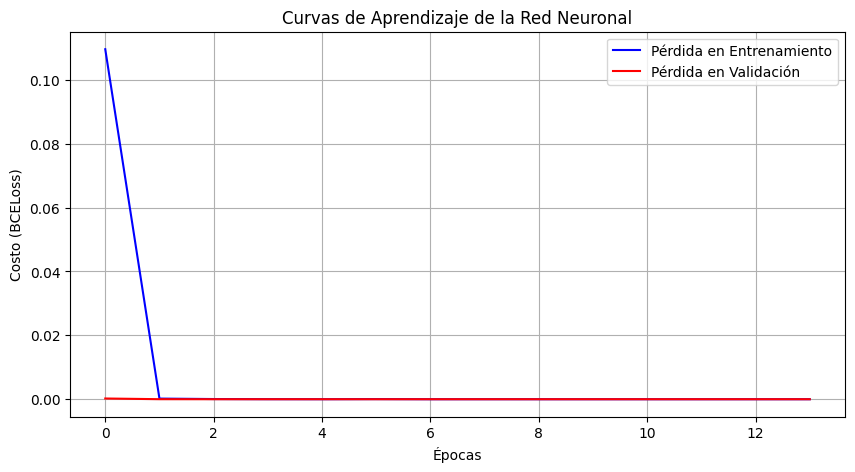

Gráfica de entrenamiento generada.


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Pérdida en Entrenamiento', color='blue')
plt.plot(val_losses, label='Pérdida en Validación', color='red')
plt.xlabel('Épocas')
plt.ylabel('Costo (BCELoss)')
plt.title('Curvas de Aprendizaje de la Red Neuronal')
plt.grid(True)
plt.legend()
plt.show()
print('Gráfica de entrenamiento generada.')